# Task 3 Solo — Plant-level Exposure Metrics (Vintage η variant)

**Identical to group Task 3 up to step 6, then adds vintage-based thermal efficiency η_p.**

**Inputs:**
- `data/processed/gppd_eu_clean.csv` — Task 1 output
- `data/raw/Global-Coal-Plant-Tracker-January-2026.xlsx`
- `data/raw/nrg_cb_pem__custom_20732263_spreadsheet.xlsx`
- `data/processed/ngfs_scenarios.csv` — Task 2 output (fuel prices in EUR2024/MWh_th)

**Outputs:**
- `data/processed/gppd_eu_metrics_solo.csv` — plant metrics with both uniform ε and vintage ε_v
- `data/processed/ngfs_cf_evolution.csv` — reused from group Task 3 (unchanged)
- `data/processed/ngfs_scenarios.csv` — used directly in Task 4 solo for vintage fuel costs

**Key addition vs group Task 3:**  
Thermal efficiency η_p is modelled as a linear function of commissioning year,  
interpolating from η_min (oldest plants, year ≤ 1950) to η_max (modern plants, year ≥ year_ref):

$$\eta_p = \eta_{\min,f} + (\eta_{\max,f} - \eta_{\min,f}) \times \frac{\min(\text{year}_p, \text{year}_{\text{ref},f}) - 1950}{\text{year}_{\text{ref},f} - 1950}$$

**Sources for η bounds:**
| Fuel | η_min | η_max | year_ref | Source |
|---|---|---|---|---|
| Coal | 0.28 | 0.45 | 2015 | IEA CCC (2016): subcritical 1950s ≈28–32%; ultra-supercritical post-2010 ≈44–46% (IEA 2020) |
| Gas  | 0.33 | 0.60 | 2010 | IEA (2020): OCGT 1970s ≈33–35%; modern CCGT ≈58–60% (JRC 2012) |
| Oil  | 0.28 | 0.40 | 2010 | IEA (2020) Table 3.11b: OCGT range 31–40% LHV |


In [14]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.3f}'.format)


### 1. Load GPPD clean dataset

In [15]:
df = pd.read_csv('../../data/processed/gppd_eu_clean.csv')
print(f"Plants: {len(df):,}  |  Fuels: {df['fuel'].value_counts().to_dict()}")


Plants: 824  |  Fuels: {'gas': 439, 'coal': 279, 'oil': 106}


### 2. Load GCPT — commissioning year imputation (coal only)

Same as group Task 3. GCPT used solely for commissioning year recovery.


In [16]:
EU27_GCPT = [
    'Austria','Belgium','Bulgaria','Croatia','Cyprus','Czech Republic','Denmark',
    'Estonia','Finland','France','Germany','Greece','Hungary','Ireland','Italy',
    'Latvia','Lithuania','Luxembourg','Malta','Netherlands','Poland','Portugal',
    'Romania','Slovakia','Slovenia','Spain','Sweden'
]
GCPT_TO_ISO3 = {
    'Austria':'AUT','Belgium':'BEL','Bulgaria':'BGR','Croatia':'HRV','Cyprus':'CYP',
    'Czech Republic':'CZE','Denmark':'DNK','Estonia':'EST','Finland':'FIN','France':'FRA',
    'Germany':'DEU','Greece':'GRC','Hungary':'HUN','Ireland':'IRL','Italy':'ITA',
    'Latvia':'LVA','Lithuania':'LTU','Luxembourg':'LUX','Malta':'MLT','Netherlands':'NLD',
    'Poland':'POL','Portugal':'PRT','Romania':'ROU','Slovakia':'SVK','Slovenia':'SVN',
    'Spain':'ESP','Sweden':'SWE'
}

gcpt_raw = pd.read_excel('../../data/raw/Global-Coal-Plant-Tracker-January-2026.xlsx', sheet_name='Units')
gcpt = gcpt_raw[
    (gcpt_raw['Country/Area'].isin(EU27_GCPT)) &
    (gcpt_raw['Status'] == 'operating')
][['Plant name','Country/Area','Capacity (MW)','Start year','Capacity factor']].copy()
gcpt['country'] = gcpt['Country/Area'].map(GCPT_TO_ISO3)

gcpt_plant = gcpt.groupby(['Plant name','country']).agg(
    capacity_gcpt   = ('Capacity (MW)', 'sum'),
    start_year_gcpt = ('Start year',    'min'),
    cf_gcpt         = ('Capacity factor','mean')
).reset_index()

print(f"GCPT plant-level EU operating: {len(gcpt_plant)}")


GCPT plant-level EU operating: 132


### 3. Fuzzy match GCPT → GPPD coal plants

In [17]:
df_coal  = df[df['fuel'] == 'coal'].copy()
df_other = df[df['fuel'] != 'coal'].copy()
MATCH_THRESHOLD = 85

for col in ['start_year_gcpt','cf_gcpt','capacity_gcpt','match_score']:
    df_coal[col] = np.nan

for country in df_coal['country'].unique():
    gppd_mask  = df_coal['country'] == country
    gcpt_mask  = gcpt_plant['country'] == country
    gppd_names = df_coal.loc[gppd_mask, 'name'].tolist()
    gcpt_names = gcpt_plant.loc[gcpt_mask, 'Plant name'].tolist()
    if not gcpt_names:
        continue
    for idx, plant_name in zip(df_coal[gppd_mask].index, gppd_names):
        result = process.extractOne(plant_name, gcpt_names, scorer=fuzz.token_sort_ratio)
        if result and result[1] >= MATCH_THRESHOLD:
            matched = gcpt_plant[
                (gcpt_plant['country'] == country) &
                (gcpt_plant['Plant name'] == result[0])
            ].iloc[0]
            df_coal.at[idx, 'start_year_gcpt'] = matched['start_year_gcpt']
            df_coal.at[idx, 'cf_gcpt']         = matched['cf_gcpt']
            df_coal.at[idx, 'capacity_gcpt']   = matched['capacity_gcpt']
            df_coal.at[idx, 'match_score']     = result[1]

n_matched = df_coal['match_score'].notna().sum()
print(f"Match rate: {n_matched}/{len(df_coal)} ({100*n_matched/len(df_coal):.1f}%)")


Match rate: 61/279 (21.9%)


### 4. Commissioning year imputation (4-priority cascade)

In [18]:
df = pd.concat([df_coal, df_other], ignore_index=True)
df['comm_year'] = df['commissioning_year']

mask = df['comm_year'].isna() & df['start_year_gcpt'].notna()
df.loc[mask, 'comm_year'] = df.loc[mask, 'start_year_gcpt']

medians = df.groupby(['country','fuel'])['comm_year'].median()
still = df['comm_year'].isna()
df.loc[still, 'comm_year'] = df.loc[still].apply(
    lambda r: medians.get((r['country'], r['fuel']), np.nan), axis=1
)

fuel_med = df.groupby('fuel')['comm_year'].median()
still = df['comm_year'].isna()
df.loc[still, 'comm_year'] = df.loc[still, 'fuel'].map(fuel_med)
df['comm_year'] = df['comm_year'].round().astype(int)

print(f"Missing after imputation: {df['comm_year'].isna().sum()}")

# Stats on imputed vs real
gppd_orig  = df['commissioning_year'].notna().sum()
gcpt_recov = (df['commissioning_year'].isna() & df['start_year_gcpt'].notna()).sum()
imputed    = len(df) - gppd_orig - gcpt_recov
print(f"GPPD original : {gppd_orig} ({gppd_orig/len(df)*100:.1f}%)")
print(f"GCPT recovered: {gcpt_recov} ({gcpt_recov/len(df)*100:.1f}%)")
print(f"Median imputed: {imputed} ({imputed/len(df)*100:.1f}%)")


Missing after imputation: 0
GPPD original : 522 (63.3%)
GCPT recovered: 1 (0.1%)
Median imputed: 301 (36.5%)


### 5. Age and remaining technical life

In [19]:
BASELINE_YEAR = 2020
LIFETIME = {'coal': 40, 'gas': 35, 'oil': 35}

df['age_2020']            = BASELINE_YEAR - df['comm_year']
df['lifetime']            = df['fuel'].map(LIFETIME)
df['remaining_life_2020'] = df['lifetime'] - df['age_2020']

print("Age distribution by fuel (2020):")
display(df.groupby('fuel')['age_2020'].describe()[['min','mean','50%','max']].round(1))
print(f"\nPlants past end-of-life in 2020: {(df['remaining_life_2020'] < 0).sum()} "
      f"({(df['remaining_life_2020'] < 0).mean()*100:.1f}%)")


Age distribution by fuel (2020):


,min,mean,50%,max
fuel,,,,
coal,3.000,41.000,40.000,112.000
gas,3.000,20.300,18.000,108.000
oil,2.000,30.600,30.000,61.000



Plants past end-of-life in 2020: 195 (23.7%)


### 6. Emission factors (IPCC 2006) — uniform per fuel

These are fuel properties and do not vary by plant vintage.  
Source: IPCC Guidelines for NGHGI 2006, Vol.2, Table 2.2.


In [20]:
# tCO2/TJ × 0.0036 = tCO2/MWh_th
EF_FUEL = {
    'coal': 94.6 * 0.0036,   # 0.3406 tCO2/MWh_th
    'gas' : 56.1 * 0.0036,   # 0.2020 tCO2/MWh_th
    'oil' : 74.1 * 0.0036,   # 0.2668 tCO2/MWh_th
}
df['ef_th'] = df['fuel'].map(EF_FUEL)

print("Emission factors (tCO2/MWh_th):")
display(df.groupby('fuel')['ef_th'].mean().round(4).to_frame())


Emission factors (tCO2/MWh_th):


,ef_th
fuel,
coal,0.341
gas,0.202
oil,0.267


### 7. Thermal efficiency — UNIFORM baseline (group model)

η uniform per fuel — kept for comparison baseline.


In [21]:
ETA_FUEL = {'coal': 0.37, 'gas': 0.50, 'oil': 0.35}

df['eta_uniform'] = df['fuel'].map(ETA_FUEL)
df['epsilon_uniform'] = df['ef_th'] / df['eta_uniform']

print("Uniform η and ε by fuel:")
display(df.groupby('fuel')[['eta_uniform','epsilon_uniform']].mean().round(4))


Uniform η and ε by fuel:


,eta_uniform,epsilon_uniform
fuel,,
coal,0.370,0.920
gas,0.500,0.404
oil,0.350,0.762


### 8. Thermal efficiency — VINTAGE model (solo extension)

η_p varies linearly with commissioning year, from η_min (oldest) to η_max (modern fleet):

$$\eta_p = \text{clip}\left(\eta_{\min,f} + (\eta_{\max,f} - \eta_{\min,f}) \times \frac{\min(\text{year}_p, \text{year}_{\text{ref},f}) - 1950}{\text{year}_{\text{ref},f} - 1950},\ \eta_{\min,f},\ \eta_{\max,f}\right)$$

**Rationale for year_ref:** plants commissioned after year_ref are assumed to have reached the  
modern efficiency plateau — further gains are marginal and not captured here.

**Caveat:** 36.5% of commissioning years are median-imputed. For these plants η_p reflects  
a group median rather than true vintage, which is a known limitation of the data.


In [22]:
# Vintage η parameters — sourced from IEA and JRC literature
# coal: IEA CCC (2016) η_min=0.28 (subcritical 1950s); IEA (2020) η_max=0.45 (USC post-2010)
# gas:  IEA (2020) η_min=0.33 (OCGT 1970s); JRC EUR 25406 EN η_max=0.60 (CCGT modern)
# oil:  IEA (2020) Table 3.11b η range 0.28–0.40 (OCGT)
ETA_VINTAGE_PARAMS = {
    'coal': {'eta_min': 0.28, 'eta_max': 0.45, 'year_ref': 2015},
    'gas':  {'eta_min': 0.33, 'eta_max': 0.60, 'year_ref': 2010},
    'oil':  {'eta_min': 0.28, 'eta_max': 0.40, 'year_ref': 2010},
}
YEAR_MIN = 1950  # floor: plants before 1950 receive η_min

def compute_eta_vintage(row):
    p    = ETA_VINTAGE_PARAMS[row['fuel']]
    year = min(int(row['comm_year']), p['year_ref'])
    year = max(year, YEAR_MIN)
    ratio = (year - YEAR_MIN) / (p['year_ref'] - YEAR_MIN)
    eta   = p['eta_min'] + (p['eta_max'] - p['eta_min']) * ratio
    return float(np.clip(eta, p['eta_min'], p['eta_max']))

df['eta_vintage']     = df.apply(compute_eta_vintage, axis=1)
df['epsilon_vintage'] = df['ef_th'] / df['eta_vintage']

print("Vintage η and ε — summary by fuel:")
display(df.groupby('fuel')[['eta_vintage','epsilon_vintage']].agg(['min','mean','max']).round(4))


Vintage η and ε — summary by fuel:


eta_vintage             epsilon_vintage            
             min  mean   max             min  mean   max
fuel                                                    
coal       0.280 0.357 0.450           0.757 0.964 1.216
gas        0.330 0.553 0.600           0.337 0.368 0.612
oil        0.298 0.358 0.400           0.667 0.748 0.895

### 9. Comparison — uniform η vs vintage η distribution

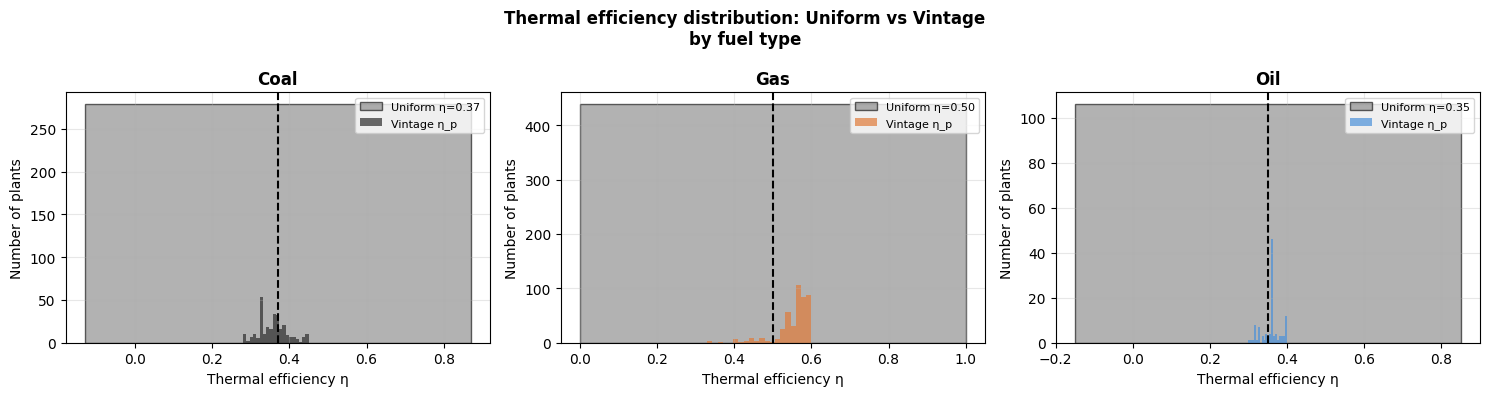


Difference in carbon intensity ε (vintage − uniform):


,Δε mean (tCO2/MWh),Δε std,Δε min,Δε max
fuel,,,,
coal,0.044,0.103,-0.164,0.296
gas,-0.036,0.039,-0.067,0.208
oil,-0.015,0.052,-0.095,0.133


In [23]:
SCENARIO_COLORS_FUEL = {'coal': '#2c2c2c', 'gas': '#e07b39', 'oil': '#4a90d9'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, fuel in zip(axes, ['coal', 'gas', 'oil']):
    sub = df[df['fuel'] == fuel]
    ax.hist(sub['eta_uniform'],  bins=1,  alpha=0.6, color='grey',
            label=f'Uniform η={ETA_FUEL[fuel]:.2f}', edgecolor='black')
    ax.hist(sub['eta_vintage'],  bins=20, alpha=0.7,
            color=SCENARIO_COLORS_FUEL[fuel], label='Vintage η_p')
    ax.axvline(ETA_FUEL[fuel], color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{fuel.capitalize()}', fontweight='bold')
    ax.set_xlabel('Thermal efficiency η')
    ax.set_ylabel('Number of plants')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Thermal efficiency distribution: Uniform vs Vintage\nby fuel type',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_eta_vintage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Difference in ε
print("\nDifference in carbon intensity ε (vintage − uniform):")
display(df.groupby('fuel').apply(
    lambda x: pd.Series({
        'Δε mean (tCO2/MWh)': (x['epsilon_vintage'] - x['epsilon_uniform']).mean().round(3),
        'Δε std':             (x['epsilon_vintage'] - x['epsilon_uniform']).std().round(3),
        'Δε min':             (x['epsilon_vintage'] - x['epsilon_uniform']).min().round(3),
        'Δε max':             (x['epsilon_vintage'] - x['epsilon_uniform']).max().round(3),
    })
))


### 10. O&M costs — identical to group model

In [24]:
OM_FUEL = {'coal': 5.0, 'gas': 4.0, 'oil': 7.0}
df['om_cost_eur_mwh'] = df['fuel'].map(OM_FUEL)


### 11. Capacity factor baseline 2020 from Eurostat

Same calibration as group Task 3. Italy uses 2022 proxy (2020 unavailable in Eurostat extract).


In [25]:
df_euro = pd.read_excel(
    '../../data/raw/nrg_cb_pem__custom_20732263_spreadsheet.xlsx',
    sheet_name='Data', header=None
)

EU27_EURO = [
    'Austria','Belgium','Bulgaria','Croatia','Cyprus','Czechia','Denmark',
    'Estonia','Finland','France','Germany','Greece','Hungary','Ireland','Italy',
    'Latvia','Lithuania','Luxembourg','Malta','Netherlands','Poland','Portugal',
    'Romania','Slovakia','Slovenia','Spain','Sweden'
]
EURO_TO_ISO3 = {
    'Austria':'AUT','Belgium':'BEL','Bulgaria':'BGR','Croatia':'HRV','Cyprus':'CYP',
    'Czechia':'CZE','Denmark':'DNK','Estonia':'EST','Finland':'FIN','France':'FRA',
    'Germany':'DEU','Greece':'GRC','Hungary':'HUN','Ireland':'IRL','Italy':'ITA',
    'Latvia':'LVA','Lithuania':'LTU','Luxembourg':'LUX','Malta':'MLT','Netherlands':'NLD',
    'Poland':'POL','Portugal':'PRT','Romania':'ROU','Slovakia':'SVK','Slovenia':'SVN',
    'Spain':'ESP','Sweden':'SWE'
}
SECTION_ROWS = {'coal': 5, 'gas': 49, 'oil': 93}
CF_MAX = 0.85

def parse_eurostat_section(df_raw, start_row):
    time_row  = start_row + 3
    time_cols = {}
    for col_idx in range(1, df_raw.shape[1], 2):
        val = df_raw.iloc[time_row, col_idx]
        if pd.notna(val):
            time_cols[str(val)] = col_idx
    records = []
    for row_idx in range(start_row + 5, df_raw.shape[0]):
        cname = df_raw.iloc[row_idx, 0]
        if pd.isna(cname): continue
        cname = str(cname).strip()
        if cname not in EU27_EURO: continue
        for t, col_idx in time_cols.items():
            val = pd.to_numeric(df_raw.iloc[row_idx, col_idx], errors='coerce')
            records.append({'country': EURO_TO_ISO3[cname], 'year_month': t,
                            'gwh': val if pd.notna(val) else 0.0})
    return pd.DataFrame(records)

euro_parts = []
for fuel, start_row in SECTION_ROWS.items():
    sec = parse_eurostat_section(df_euro, start_row)
    sec['fuel'] = fuel
    euro_parts.append(sec)

euro_long = pd.concat(euro_parts, ignore_index=True)
euro_long['year'] = euro_long['year_month'].str[:4].astype(int)

# Primary 2020, fallback 2022 (Italy)
gwh_by_year = euro_long.groupby(['country','fuel','year'])['gwh'].sum().reset_index()
gwh_2020 = (gwh_by_year[gwh_by_year['year'] == 2020]
            .rename(columns={'gwh':'gwh_2020'}).drop(columns='year'))
gwh_2022 = (gwh_by_year[gwh_by_year['year'] == 2022]
            .rename(columns={'gwh':'gwh_2022'}).drop(columns='year'))
euro_2020 = gwh_2020.merge(gwh_2022, on=['country','fuel'], how='left')
fallback_mask = (euro_2020['gwh_2020'] == 0) & (euro_2020['gwh_2022'].fillna(0) > 0)
print(f"2022 proxy used for {fallback_mask.sum()} (country,fuel) pairs (Italy 2020 unavailable):")
if fallback_mask.any():
    print(euro_2020[fallback_mask][['country','fuel']].to_string(index=False))
euro_2020.loc[fallback_mask, 'gwh_2020'] = euro_2020.loc[fallback_mask, 'gwh_2022']
euro_2020 = euro_2020[['country','fuel','gwh_2020']]

cap_cf = df.groupby(['country','fuel'])['capacity_mw'].sum().reset_index().rename(columns={'capacity_mw':'cap_mw'})
cf_base = euro_2020.merge(cap_cf, on=['country','fuel'], how='left')
cf_base['cf_baseline'] = cf_base['gwh_2020'] / (cf_base['cap_mw'] * 8760 / 1000)
cf_base['cf_baseline'] = cf_base['cf_baseline'].clip(upper=CF_MAX).fillna(0.0)

df = df.merge(cf_base[['country','fuel','cf_baseline']], on=['country','fuel'], how='left')
df['cf_baseline'] = df['cf_baseline'].fillna(0.0)

print("\nCF baseline 2020 by fuel:")
display(cf_base.groupby('fuel')['cf_baseline'].describe()[['min','mean','50%','max']].round(3))

# Residual CF=0 check
zero_cf = df[df['cf_baseline'] == 0.0]
print(f"\nCF=0 residual: {len(zero_cf)} plants / {zero_cf['capacity_mw'].sum():,.0f} MW "
      f"({zero_cf['capacity_mw'].sum()/df['capacity_mw'].sum()*100:.1f}%)")
print(zero_cf.groupby(['country','fuel']).agg(n=('gppd_idnr','count'), cap_mw=('capacity_mw','sum')))


2022 proxy used for 3 (country,fuel) pairs (Italy 2020 unavailable):
country fuel
    ITA coal
    ITA  gas
    ITA  oil

CF baseline 2020 by fuel:


,min,mean,50%,max
fuel,,,,
coal,0.000,0.434,0.422,0.850
gas,0.000,0.376,0.341,0.850
oil,0.000,0.085,0.000,0.850



CF=0 residual: 6 plants / 2,919 MW (0.9%)
              n    cap_mw
country fuel             
EST     gas   2   423.000
        oil   2 1,841.000
POL     oil   2   655.000


### 12. Save output — gppd_eu_metrics_solo.csv

In [26]:
COLS_FINAL = [
    'gppd_idnr', 'name', 'country', 'country_long',
    'fuel', 'capacity_mw',
    'comm_year', 'age_2020', 'lifetime', 'remaining_life_2020',
    'ef_th',
    'eta_uniform',    'epsilon_uniform',
    'eta_vintage',    'epsilon_vintage',
    'om_cost_eur_mwh',
    'cf_baseline',
    'latitude', 'longitude',
]

cols_present = [c for c in COLS_FINAL if c in df.columns]
df_out = df[cols_present].copy().reset_index(drop=True)

df_out = df_out.rename(columns={
    'comm_year'           : 'commissioning_year',
    'age_2020'            : 'age_2020_years',
    'remaining_life_2020' : 'remaining_life_2020_years',
    'om_cost_eur_mwh'     : 'om_variable_eur2024_per_MWh',
    'cf_baseline'         : 'capacity_factor_2020',
})

df_out.to_csv('../../data/processed/gppd_eu_metrics_vintage.csv', index=False)
print(f"Saved: gppd_eu_metrics_vintage.csv  |  Shape: {df_out.shape}")
print()
print("Summary by fuel:")
display(df_out.groupby('fuel')[[
    'capacity_mw', 'age_2020_years',
    'epsilon_uniform', 'epsilon_vintage',
    'om_variable_eur2024_per_MWh', 'capacity_factor_2020'
]].mean().round(3))


Saved: gppd_eu_metrics_vintage.csv  |  Shape: (824, 19)

Summary by fuel:


,capacity_mw,age_2020_years,epsilon_uniform,epsilon_vintage,om_variable_eur2024_per_MWh,capacity_factor_2020
fuel,,,,,,
coal,513.463,41.014,0.920,0.964,5.000,0.489
gas,323.846,20.251,0.404,0.368,4.000,0.386
oil,272.943,30.566,0.762,0.748,7.000,0.146
